# 02 - PCA Analysis

Dimensionality reduction on the processed train/test matrices.


In [1]:
from pathlib import Path
from IPython.display import display
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

TRAIN_TEST_DIR = Path('../data/train_test')
MODEL_DIR = Path('../models')
print('Environment ready')


Environment ready


In [2]:
X_train = pd.read_csv(TRAIN_TEST_DIR / 'X_train_processed.csv')
X_test = pd.read_csv(TRAIN_TEST_DIR / 'X_test_processed.csv')
y_train = pd.read_csv(TRAIN_TEST_DIR / 'y_train.csv')
y_test = pd.read_csv(TRAIN_TEST_DIR / 'y_test.csv')
print('X_train:', X_train.shape, 'X_test:', X_test.shape)
print('y_train:', y_train.shape, 'y_test:', y_test.shape)
display(X_train.head())


X_train: (3497, 134) X_test: (875, 134)
y_train: (3497, 1) y_test: (875, 1)


,0,1,2,3,4,5,6,7,8,9,...,124,125,126,127,128,129,130,131,132,133
0,-0.807138,-0.319971,-0.145613,-0.159680,-0.032193,0.032869,-0.048815,-0.188643,-0.156093,0.027594,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.322707,-0.319971,-0.238353,-0.082481,-0.026888,0.033398,-0.045211,-0.286402,-0.145869,0.027594,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.616076,-0.319971,-0.168811,-0.062023,-0.032952,0.036088,-0.052543,-0.225998,-0.108547,0.028130,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.399084,0.291861,0.058025,-0.007119,-0.029165,0.031159,-0.037630,0.122121,-0.002101,0.024381,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.399084,-0.014055,-0.036913,-0.113600,-0.029006,0.032683,-0.019175,-0.072338,-0.122101,0.027594,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [3]:
pca_full = PCA()
pca_full.fit(X_train)
explained = pca_full.explained_variance_ratio_
cumulative = explained.cumsum()
variance_table = pd.DataFrame({
    'component': np.arange(1, len(explained) + 1),
    'explained_variance': explained,
    'cumulative_variance': cumulative,
})
print('First PCA components')
display(variance_table.head(15).round(4))


First PCA components


,component,explained_variance,cumulative_variance
0,1,0.1727,0.1727
1,2,0.1090,0.2817
2,3,0.0688,0.3505
3,4,0.0589,0.4094
4,5,0.0505,0.4599
5,6,0.0428,0.5027
6,7,0.0384,0.5411
7,8,0.0313,0.5724
8,9,0.0291,0.6015
9,10,0.0275,0.6290


In [4]:
threshold_summary = []
for threshold in [0.70, 0.80, 0.85, 0.90, 0.95]:
    n_components = int(np.argmax(cumulative >= threshold) + 1)
    threshold_summary.append({'variance_threshold': threshold, 'components_required': n_components})
threshold_summary = pd.DataFrame(threshold_summary)
print('Components required by explained variance threshold')
display(threshold_summary)


Components required by explained variance threshold


,variance_threshold,components_required
0,0.70,13
1,0.80,18
2,0.85,22
3,0.90,29
4,0.95,38


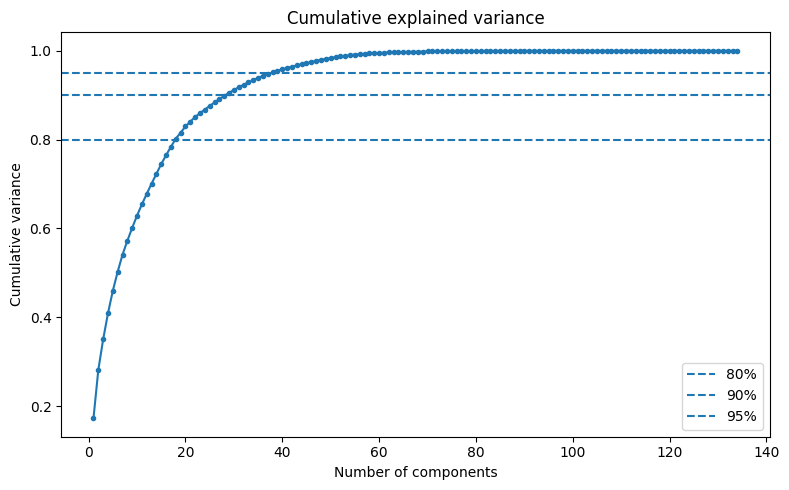

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(variance_table['component'], variance_table['cumulative_variance'], marker='o', markersize=3)
for threshold in [0.80, 0.90, 0.95]:
    ax.axhline(threshold, linestyle='--', label=f'{int(threshold * 100)}%')
ax.set_title('Cumulative explained variance')
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative variance')
ax.legend()
plt.tight_layout()
plt.show()


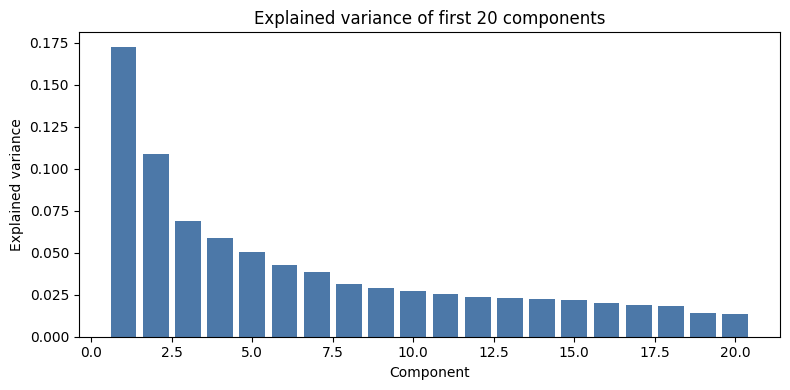

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(variance_table['component'].head(20), variance_table['explained_variance'].head(20), color='#4c78a8')
ax.set_title('Explained variance of first 20 components')
ax.set_xlabel('Component')
ax.set_ylabel('Explained variance')
plt.tight_layout()
plt.show()


In [7]:
projections = {}
for threshold in [0.80, 0.90]:
    pca = PCA(n_components=threshold)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    projections[int(threshold * 100)] = (pca, X_train_pca, X_test_pca)
    print(f'{int(threshold * 100)}% PCA -> train {X_train_pca.shape}, test {X_test_pca.shape}, retained variance {pca.explained_variance_ratio_.sum():.4f}')


80% PCA -> train (3497, 18), test (875, 18), retained variance 0.8019
90% PCA -> train (3497, 29), test (875, 29), retained variance 0.9051


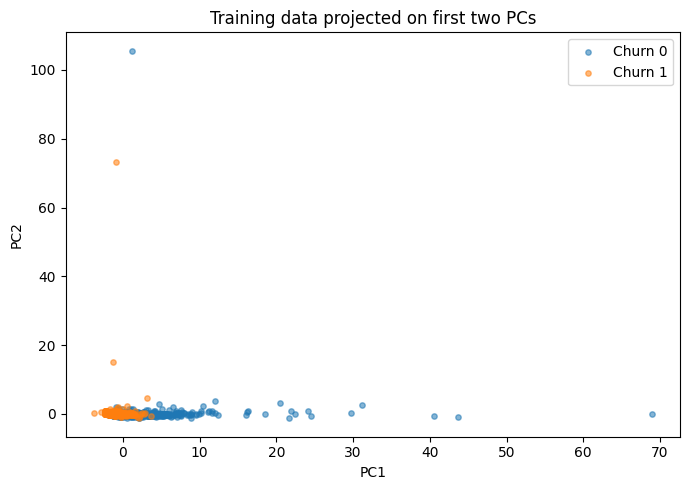

In [8]:
pca_80, X_train_pca_80, X_test_pca_80 = projections[80]
plot_df = pd.DataFrame({'PC1': X_train_pca_80[:, 0], 'PC2': X_train_pca_80[:, 1], 'Churn': y_train.squeeze()})
fig, ax = plt.subplots(figsize=(7, 5))
for churn_value, subset in plot_df.groupby('Churn'):
    ax.scatter(subset['PC1'], subset['PC2'], s=15, alpha=0.55, label=f'Churn {churn_value}')
ax.set_title('Training data projected on first two PCs')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
plt.tight_layout()
plt.show()


In [9]:
existing_outputs = []
for path in sorted(TRAIN_TEST_DIR.glob('*pca*.csv')):
    existing_outputs.append({'file': path.name, 'shape': pd.read_csv(path).shape})
for path in sorted(MODEL_DIR.glob('pca_*.joblib')):
    model = joblib.load(path)
    existing_outputs.append({'file': path.name, 'shape': f'{model.n_components_} components'})
print('Existing PCA artifacts')
display(pd.DataFrame(existing_outputs))


Existing PCA artifacts


,file,shape
0,X_test_pca_80.csv,"(875, 18)"
1,X_test_pca_90.csv,"(875, 29)"
2,X_train_pca_80.csv,"(3497, 18)"
3,X_train_pca_90.csv,"(3497, 29)"
4,pca_80.joblib,18 components
5,pca_90.joblib,29 components


In [10]:
comparison = pd.DataFrame({
    'dataset': ['X_train_processed', 'X_train_pca_80', 'X_train_pca_90'],
    'columns': [X_train.shape[1], projections[80][1].shape[1], projections[90][1].shape[1]],
})
comparison['reduction_percent'] = (1 - comparison['columns'] / X_train.shape[1]).round(4) * 100
print('Dimensionality reduction summary')
display(comparison)


Dimensionality reduction summary


,dataset,columns,reduction_percent
0,X_train_processed,134,0.00
1,X_train_pca_80,18,86.57
2,X_train_pca_90,29,78.36


## PCA conclusion

PCA keeps most information while reducing the number of columns. The classification notebook compares models with and without PCA.
